## Named Entity Recognition (NER)

---

## Part 1: Setup and Data Loading

In [8]:
!pip install spacy datasets pandas matplotlib seaborn -q
!python -m spacy download en_core_web_sm -q

import spacy
from spacy import displacy  # For visual NER rendering
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

nlp = spacy.load("en_core_web_sm")
print("✅ spaCy loaded!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 95.3 MB/s eta 0:00:0000:010:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ spaCy loaded!


In [9]:
from datasets import load_dataset

# Load dataset
dataset = load_dataset("stanfordnlp/imdb", split="train[:5000]")
df = dataset.to_pandas()

print(f"✅ Loaded {len(df):,} reviews")

✅ Loaded 5,000 reviews


## Part 2: Understanding NER Entity Types

In [10]:
# Demo NER on sample text
sample_text = """
Apple CEO Tim Cook announced the new iPhone 15 in San Francisco yesterday.
The product costs $999 and will be available in the United States starting
September 22, 2024. Amazon and Best Buy will also carry the device.
"""

doc = nlp(sample_text)

print("📊 NAMED ENTITIES FOUND")
print("-" * 60)
for ent in doc.ents:
    print(f"{ent.text:20} | {ent.label_:10} | {spacy.explain(ent.label_)}")

# 🎨 Visual representation - see entities highlighted in context!
print("\n" + "=" * 60)
print("🎨 VISUAL NER (entities highlighted in text):")
displacy.render(doc, style="ent", jupyter=True)

📊 NAMED ENTITIES FOUND
------------------------------------------------------------
Apple                | ORG        | Companies, agencies, institutions, etc.
Tim Cook             | PERSON     | People, including fictional
15                   | CARDINAL   | Numerals that do not fall under another type
San Francisco        | GPE        | Countries, cities, states
yesterday            | DATE       | Absolute or relative dates or periods
999                  | MONEY      | Monetary values, including unit
the United States    | GPE        | Countries, cities, states
September 22, 2024   | DATE       | Absolute or relative dates or periods
Amazon               | ORG        | Companies, agencies, institutions, etc.
Best Buy             | PERSON     | People, including fictional

🎨 VISUAL NER (entities highlighted in text):


named_entity_recognition.svg

In [11]:
# Try another example - a movie review style text
movie_review = """
Christopher Nolan's Inception starring Leonardo DiCaprio was filmed in Los Angeles 
and Paris. Warner Bros released it in July 2010 for $160 million. The film won 
four Academy Awards and grossed over $830 million worldwide.
"""

movie_doc = nlp(movie_review)

print("🎬 MOVIE REVIEW NER")
print("-" * 60)
for ent in movie_doc.ents:
    print(f"{ent.text:25} | {ent.label_:10} | {spacy.explain(ent.label_)}")

print("\n" + "=" * 60)
print("🎨 VISUAL REPRESENTATION:")
displacy.render(movie_doc, style="ent", jupyter=True)

🎬 MOVIE REVIEW NER
------------------------------------------------------------
Christopher Nolan's       | PERSON     | People, including fictional
Leonardo DiCaprio         | PERSON     | People, including fictional
Los Angeles               | GPE        | Countries, cities, states
Paris                     | GPE        | Countries, cities, states
Warner Bros               | ORG        | Companies, agencies, institutions, etc.
July 2010                 | DATE       | Absolute or relative dates or periods
$160 million              | MONEY      | Monetary values, including unit
four                      | CARDINAL   | Numerals that do not fall under another type
Academy Awards            | ORG        | Companies, agencies, institutions, etc.
over $830 million         | MONEY      | Monetary values, including unit

🎨 VISUAL REPRESENTATION:


## Part 3: Extract Entities from Reviews

In [12]:
def extract_entities(text):
    """Extract named entities from text."""
    doc = nlp(str(text)[:5000])  # Limit for speed
    entities = {
        'ORG': [],
        'PRODUCT': [],
        'GPE': [],
        'PERSON': [],
    }
    for ent in doc.ents:
        if ent.label_ in entities:
            entities[ent.label_].append(ent.text)
    return entities

# Extract from all reviews
print("Extracting entities (this takes 1-2 minutes)...")

all_orgs = []
all_products = []
all_locations = []
all_persons = []

for idx, row in df.iterrows():
    if idx % 500 == 0:
        print(f"   Processing {idx}/{len(df)}...")
    entities = extract_entities(row['text'])
    all_orgs.extend(entities['ORG'])
    all_products.extend(entities['PRODUCT'])
    all_locations.extend(entities['GPE'])
    all_persons.extend(entities['PERSON'])

print(f"\n✅ Extraction complete!")
print(f"   ORG: {len(all_orgs):,}")
print(f"   PRODUCT: {len(all_products):,}")
print(f"   GPE: {len(all_locations):,}")
print(f"   PERSON: {len(all_persons):,}")

Extracting entities (this takes 1-2 minutes)...
   Processing 0/5000...
   Processing 500/5000...
   Processing 1000/5000...
   Processing 1500/5000...
   Processing 2000/5000...
   Processing 2500/5000...
   Processing 3000/5000...
   Processing 3500/5000...
   Processing 4000/5000...
   Processing 4500/5000...

✅ Extraction complete!
   ORG: 7,962
   PRODUCT: 485
   GPE: 3,791
   PERSON: 19,152


## Part 4: Analyze Entity Patterns

In [13]:
# Most common entities
org_counts = Counter(all_orgs).most_common(15)
person_counts = Counter(all_persons).most_common(15)
location_counts = Counter(all_locations).most_common(10)

print("📊 TOP ORGANIZATIONS")
print("-" * 40)
for org, count in org_counts:
    print(f"{org:25} | {count}")

print("\n📊 TOP PEOPLE")
print("-" * 40)
for person, count in person_counts:
    print(f"{person:25} | {count}")

print("\n📊 TOP LOCATIONS")
print("-" * 40)
for loc, count in location_counts:
    print(f"{loc:25} | {count}")

📊 TOP ORGANIZATIONS
----------------------------------------
Disney                    | 89
Keaton                    | 70
Batman                    | 43
Caine                     | 41
Fulci                     | 39
VHS                       | 37
FX                        | 35
CGI                       | 35
MST3K                     | 34
/>Well                    | 32
BBC                       | 31
BAD                       | 30
MTV                       | 26
FBI                       | 25
Karloff                   | 24

📊 TOP PEOPLE
----------------------------------------
gore                      | 238
Hitler                    | 107
Oscar                     | 92
Jesus                     | 59
Freddy                    | 52
Kate                      | 49
Carlito                   | 47
Jack                      | 43
Dracula                   | 43
Shakespeare               | 40
Cinderella                | 40
Mike                      | 40
Jackson                   | 40
Lee           

## Part 5: Visualization

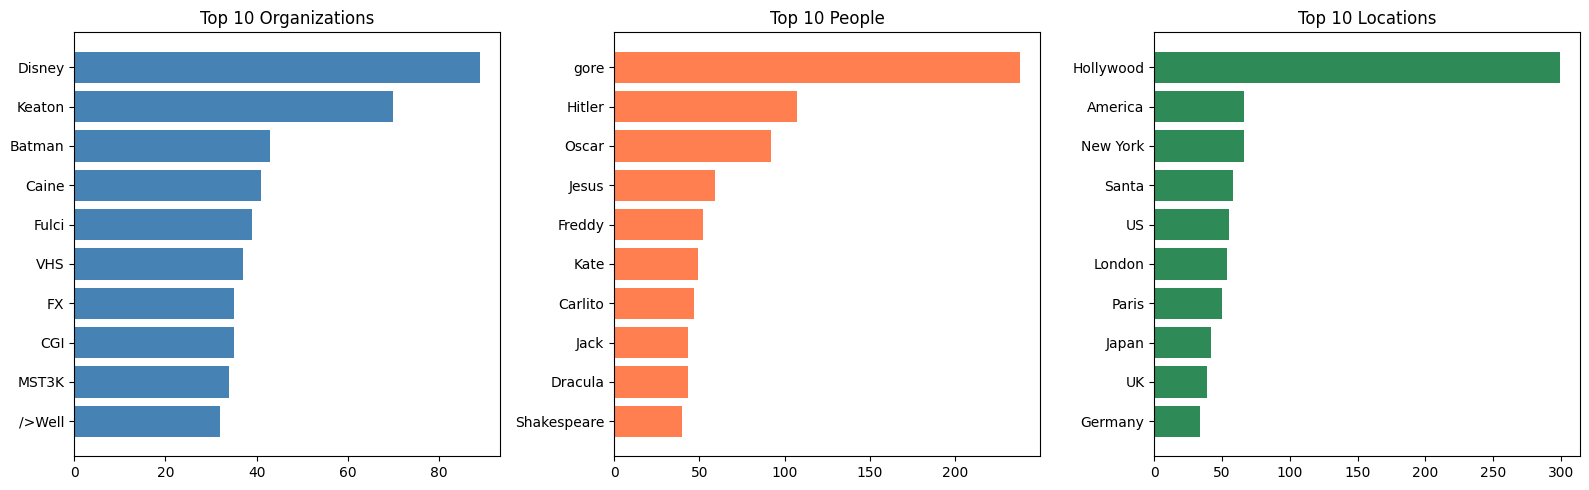

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Organizations
if org_counts:
    orgs, counts = zip(*org_counts[:10])
    axes[0].barh(orgs, counts, color='steelblue')
    axes[0].set_title('Top 10 Organizations')
    axes[0].invert_yaxis()

# People
if person_counts:
    persons, counts = zip(*person_counts[:10])
    axes[1].barh(persons, counts, color='coral')
    axes[1].set_title('Top 10 People')
    axes[1].invert_yaxis()

# Locations
if location_counts:
    locs, counts = zip(*location_counts[:10])
    axes[2].barh(locs, counts, color='seagreen')
    axes[2].set_title('Top 10 Locations')
    axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('ner_analysis.png', dpi=150)
plt.show()